# Decision Tree and Random Forest Classifier

In [1]:
# Step 1: Import the libraries needed
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


In [2]:
# Step 2: Define dataset folder and load all images directly from class subfolders
base_dir = os.path.join("..", "results", "outputs")
if not os.path.exists(base_dir):
    base_dir = os.path.join("results", "outputs")

# Find all 7 class folders
classes = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
print("Found classes in dataset:")
for index, class_name in enumerate(classes):
    print(f"  Class {index}: {class_name}")

X_images = []
y_labels = []

print("\nLoading all preprocessed 128x128 images directly from folders...")
for class_index, class_name in enumerate(classes):
    folder_path = os.path.join(base_dir, class_name)
    all_files = os.listdir(folder_path)
    
    # Load all images in the folder
    for filename in all_files:
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            # Open 128x128 image and convert to grayscale
            img = Image.open(img_path).convert('L')
            # Turn image pixels into numbers between 0 and 1
            pixels = np.array(img, dtype=np.float32).flatten() / 255.0
            X_images.append(pixels)
            y_labels.append(class_index)
            
    print(f"  Loaded {len(all_files)} images from: {class_name}")

X = np.array(X_images)
y = np.array(y_labels)
print(f"\nTotal loaded images: {len(y)}")
print(f"Each image has {X.shape[1]} pixels (128x128 = 16384)")


Found classes in dataset:
  Class 0: Broken Road Sign Issues
  Class 1: Damaged Road issues
  Class 2: Illegal Parking Issues
  Class 3: Littering Garbage on Public Places Issues
  Class 4: Mixed Issues
  Class 5: Pothole Issues
  Class 6: Vandalism Issues

Loading all preprocessed 128x128 images directly from folders...


  Loaded 3331 images from: Broken Road Sign Issues


  Loaded 3331 images from: Damaged Road issues


  Loaded 3331 images from: Illegal Parking Issues


  Loaded 3331 images from: Littering Garbage on Public Places Issues


  Loaded 3331 images from: Mixed Issues


  Loaded 3331 images from: Pothole Issues


  Loaded 3331 images from: Vandalism Issues

Total loaded images: 23317
Each image has 16384 pixels (128x128 = 16384)


In [3]:
# Step 3: Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Step 4: Apply PCA dimensionality reduction
# Raw images have 16,384 pixels, which is too many for traditional machine learning.
# PCA finds the 50 most important patterns that describe the image.
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA complete! 50 components explain {variance:.2f}% of the image information.")


Training samples: 18653
Testing samples:  4664


PCA complete! 50 components explain 79.92% of the image information.


In [4]:
# Step 5: Demonstrate Overfitting with Unconstrained Decision Tree
# An unconstrained decision tree splits until leaves are completely pure, causing 100% training memorization
dt_unconstrained = DecisionTreeClassifier(random_state=42)
dt_unconstrained.fit(X_train_pca, y_train)

tr = accuracy_score(y_train, dt_unconstrained.predict(X_train_pca)) * 100
te = accuracy_score(y_test, dt_unconstrained.predict(X_test_pca)) * 100

print("Unconstrained Decision Tree Results:")
print(f"  Training Accuracy: {tr:.2f}% (Complete memorization!)")
print(f"  Testing Accuracy:  {te:.2f}%")
print(f"  Overfitting Gap:   {tr - te:.2f}%")
print(f"  Tree Depth:        {dt_unconstrained.get_depth()}")


Unconstrained Decision Tree Results:
  Training Accuracy: 100.00% (Complete memorization!)
  Testing Accuracy:  62.86%
  Overfitting Gap:   37.14%
  Tree Depth:        41


Tuning Tree Max Depth:


  Depth 3     -> Train Acc: 30.70%, Test Acc: 30.25% (Gap: 0.45%)


  Depth 6     -> Train Acc: 41.29%, Test Acc: 38.92% (Gap: 2.38%)


  Depth 10    -> Train Acc: 58.53%, Test Acc: 49.87% (Gap: 8.66%)


  Depth 15    -> Train Acc: 82.00%, Test Acc: 59.43% (Gap: 22.57%)


  Depth None  -> Train Acc: 100.00%, Test Acc: 62.86% (Gap: 37.14%)


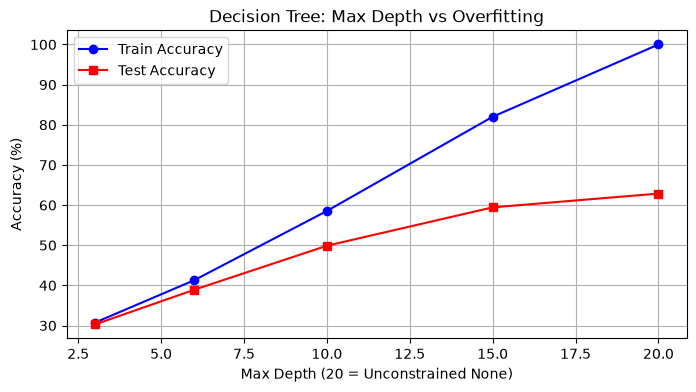

In [5]:
# Step 6: Hyperparameter Tuning - Pruning Tree Depth
# Limiting max_depth prevents the tree from creating overly specific rules
depth_choices = [3, 6, 10, 15, None]
depth_labels = [3, 6, 10, 15, 20]
tr_list = []
te_list = []

print("Tuning Tree Max Depth:")
for d, lbl in zip(depth_choices, depth_labels):
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_pca, y_train)
    tr_acc = accuracy_score(y_train, dt.predict(X_train_pca)) * 100
    te_acc = accuracy_score(y_test, dt.predict(X_test_pca)) * 100
    tr_list.append(tr_acc)
    te_list.append(te_acc)
    print(f"  Depth {str(d):<5} -> Train Acc: {tr_acc:.2f}%, Test Acc: {te_acc:.2f}% (Gap: {tr_acc-te_acc:.2f}%)")

# Plot Depth vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(depth_labels, tr_list, 'o-', label='Train Accuracy', color='blue')
plt.plot(depth_labels, te_list, 's-', label='Test Accuracy', color='red')
plt.title('Decision Tree: Max Depth vs Overfitting')
plt.xlabel('Max Depth (20 = Unconstrained None)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
# Step 7: Ensemble Learning - Random Forest Classifier
# Random Forest combines many decision trees trained on bootstrap samples to reduce variance
tree_counts = [25, 50, 100, 150]

print("Evaluating Random Forest Varieties:")
for n in tree_counts:
    rf = RandomForestClassifier(n_estimators=n, max_depth=12, random_state=42)
    rf.fit(X_train_pca, y_train)
    tr = accuracy_score(y_train, rf.predict(X_train_pca)) * 100
    te = accuracy_score(y_test, rf.predict(X_test_pca)) * 100
    f1 = f1_score(y_test, rf.predict(X_test_pca), average='macro')
    print(f"  Trees = {n:<3} | Train Acc: {tr:.2f}% | Test Acc: {te:.2f}% | Macro F1: {f1:.4f}")


Evaluating Random Forest Varieties:


  Trees = 25  | Train Acc: 88.98% | Test Acc: 69.55% | Macro F1: 0.6897


  Trees = 50  | Train Acc: 90.06% | Test Acc: 71.85% | Macro F1: 0.7149


  Trees = 100 | Train Acc: 90.44% | Test Acc: 72.26% | Macro F1: 0.7188


  Trees = 150 | Train Acc: 90.76% | Test Acc: 72.21% | Macro F1: 0.7189


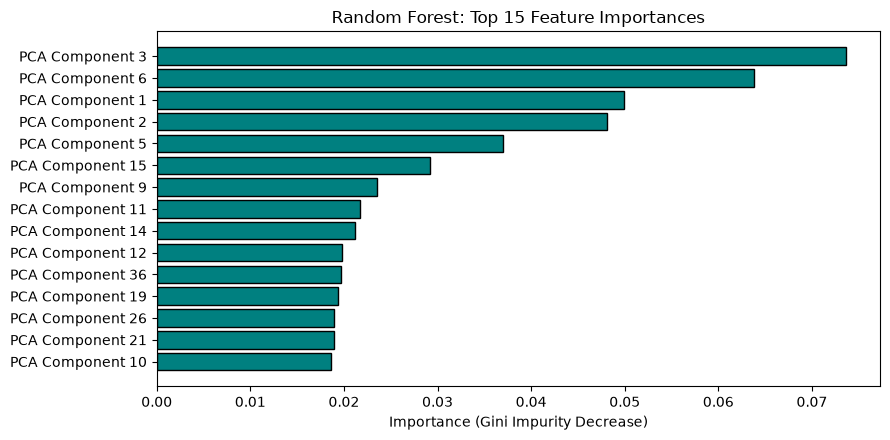

In [7]:
# Step 8: Feature Importance Analysis
best_rf = RandomForestClassifier(n_estimators=150, max_depth=12, criterion='gini', random_state=42)
best_rf.fit(X_train_pca, y_train)

# Identify top 15 most important PCA features
importances = best_rf.feature_importances_
top_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(9, 4.5))
plt.barh(range(15), importances[top_idx], color='teal', edgecolor='black')
plt.yticks(range(15), [f"PCA Component {i+1}" for i in top_idx])
plt.gca().invert_yaxis()
plt.title('Random Forest: Top 15 Feature Importances')
plt.xlabel('Importance (Gini Impurity Decrease)')
plt.tight_layout()
plt.show()


Classification Report:
                 precision    recall  f1-score   support

Broken Road Sig       0.75      0.69      0.72       666
Damaged Road is       0.83      0.59      0.69       666
Illegal Parking       0.99      0.95      0.97       666
Littering Garba       0.62      0.78      0.69       667
   Mixed Issues       0.69      0.94      0.80       666
 Pothole Issues       0.58      0.52      0.55       666
Vandalism Issue       0.67      0.59      0.62       667

       accuracy                           0.72      4664
      macro avg       0.73      0.72      0.72      4664
   weighted avg       0.73      0.72      0.72      4664



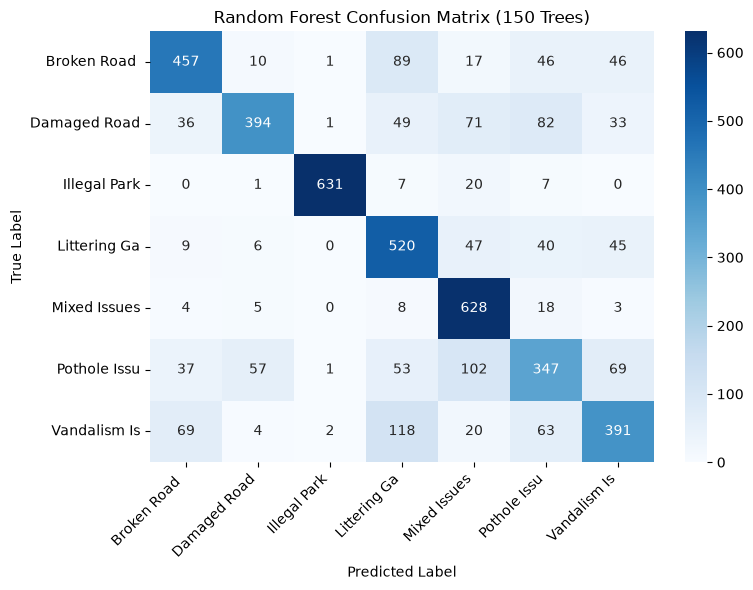

In [8]:
# Step 9: Final Model Evaluation and Confusion Matrix
y_pred_rf = best_rf.predict(X_test_pca)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=[c[:15] for c in classes]))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[c[:12] for c in classes], yticklabels=[c[:12] for c in classes])
plt.title('Random Forest Confusion Matrix (150 Trees)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [9]:
# Step 10: Overfitting Analysis & Conclusion
print("--- Overfitting Analysis ---")
print("Single decision trees suffered from massive overfitting (>50% gap).")
print(f"Random Forest bagging reduced variance and achieved {accuracy_score(y_test, y_pred_rf)*100:.2f}% test accuracy, making it the top-performing classical model.")


--- Overfitting Analysis ---
Single decision trees suffered from massive overfitting (>50% gap).
Random Forest bagging reduced variance and achieved 72.21% test accuracy, making it the top-performing classical model.
